In [1]:
##modules
#%matplotlib widget
%matplotlib inline
#
#%matplotlib qt
import mne
import numpy as np
import matplotlib
# Establecer un backend interactivo, como 'Qt5Agg', 'GTK3Agg', etc.
# Esto depende de los backends disponibles en tu sistema.

import matplotlib.pyplot as plt

#matplotlib.use('TkAgg')  # Asegúrate de que este backend está instalado.

import pandas as pd 
import os
import sys

from mne.preprocessing import ICA, corrmap, create_ecg_epochs, create_eog_epochs

from os.path import join as pathjoin
from time import time

from pathlib import Path

from autoreject import AutoReject

# aplicar la acf EN epochs

from statsmodels.tsa.stattools import acf


from scipy.stats import permutation_test
sys.path.append(r"G:\apuntes_mne\code_MOUS\scripts_functions_created")

# Ahora importa la función
from print5 import print5


import pickle

from scipy.stats import gaussian_kde
import numpy as np
import matplotlib.pyplot as plt

In [2]:

try:
    # Si se ejecuta como SCRIPT .py: usar __file__
    sys.path.append(os.path.abspath(os.path.join(os.path.dirname(__file__), "..")))
except NameError:
    # Si se ejecuta como NOTEBOOK Jupyter: usar path relativo
    sys.path.append("..")  # sube un nivel desde la carpeta actual del notebook


# --- Configuración dinámica de rutas ---
from get_paths_MOUS import get_paths_MOUS

# Parámetros editables
disco = "g"
modality = "visual"
layer_script = "event"
subj = "sub-V1001"
#subj = sys.argv[1] ## name of participant list


# Generar variables automáticamente
path_dict = get_paths_MOUS(disco=disco, modality=modality, layer_script=layer_script, subj=subj)
globals().update(path_dict)

# Mostrar todos los paths generados
print("\n📁 Rutas generadas:")
for k, v in path_dict.items():
    print(f"{k:<20} → {v}")
    
        
    
with open(datadir / f"subjects_remove_{modality}.pkl", "rb") as f:
    subjects_remove = pickle.load(f)
    



📁 Rutas generadas:
datadir              → g:\MOUS_204\MOUS_visual
general_datadir      → g:\MOUS_204
output_preproc       → g:\MOUS_204\MOUS_visual\output_preproc
mri_dir              → g:\MOUS_204\sub-V1001\anat
meg_dir              → g:\MOUS_204\sub-V1001\meg
preproc_path         → g:\MOUS_204\MOUS_visual\output_preproc\preproc_event
channels_structure_path → g:\MOUS_204\channels_structure
epochs_path          → g:\MOUS_204\MOUS_visual\output_preproc\preproc_event\epochs_event
ICA_path             → g:\MOUS_204\MOUS_visual\output_preproc\preproc_event\ICA_event
epochs_clean_path    → g:\MOUS_204\MOUS_visual\output_preproc\preproc_event\epochs_clean_event
evoked_path          → g:\MOUS_204\MOUS_visual\output_preproc\preproc_event\evoked_event
source_path          → g:\MOUS_204\MOUS_visual\output_source\source_event
raw_hsp_path         → g:\MOUS_204\MOUS_visual\output_source\source_event\raw_hsp
fwd_path             → g:\MOUS_204\MOUS_visual\output_source\source_event\fwd
inverse_pat

# Tables and paths
Now, as specially in the event_preprocessing we are going to work with lots of different comparisons, we are going to create, instead of variables only, we are going to use comparisons 

Example: comparison_1= [zinnen, woorden]
so variable 1= comparison_1[0]

then we will create a for loop, to print analysis for all conditions

### Paths
ACW_path
PLE_path

### Tables and metrics
#### Block

*ACW*


f"acw_results_subjects_all_{layer_script}.pickle" 
if you want the acf and the whole table   f"autocorrelation_subjects_all_{layer_script}.pickle"

f"autocorrelation_subjects_all_{layer_script}.pickle"

**variables** =  acw_50_elect_all_epoch_all //  'intercept_y_elect_all_epoch_all', 'slope_elect_all_epoch_all'


*PLE*
f"table_PLE_slope_intercept_subjects_all_{layer_script}.pickle"

f"table_PLE_subjects_all_{layer_script}.pickle"


#### dynamic

f"dynamic_autocorrelation_results_subjects_all_{layer_script}.pickle"

f"dynamic_autocorrelation_subjects_all_{layer_script}.pickle"

**variables** = acw_50_slope_elect_all_epoch_all   // acw_50_std_elect_all_epoch_all 

table_df_comp

In [12]:
dynamic=False
## Variables of script
filtering=True
if filtering==True:
    lfreq=1
    hfreq=40
    filter_name= f"filt_{lfreq}-{hfreq}"
    print(f"Filtrado aplicado: {lfreq}-{hfreq} Hz")
elif filtering==False:
    print("No se ha aplicado filtrado.")
    
## Variables of script
##path=analysis_path
path = ACW_path
if filtering:
    if dynamic==False:
        name_table = f"acw_results_subjects_all_{filter_name}_{layer_script}.pickle" 
    if dynamic==True:
        name_table=f"dynamic_autocorrelation_results_subjects_all_{filter_name}_{layer_script}.pickle"
else:   
    name_table = f"acw_results_subjects_all_{layer_script}.pickle" 

table_df = pd.read_pickle(f"{path}\\{name_table}")

# Extraer sujetos del dataframe
subjects = table_df["Subject"].unique()

# Filtrar sujetos eliminados
subjects = [s for s in subjects if s not in subjects_remove]

# Filtrar tabla también
table_df = table_df.query("Subject in @subjects")



# Remove them also from table
#METRIC NAMES
metric="acw_50_elect_all_epoch_all"



if '_elect_all_epoch_all' in metric:
    print("yes")
    metric_name = metric.replace('_elect_all_epoch_all', "")
else:
    metric_name = metric
    
##CONDITION NAMES
if layer_script == "event":
    zinnen_noQ = ["zinnen_RC_plus", "zinnen_RC_neg"]
    woorden_noQ = ["woorden_RC_plus", "woorden_RC_neg"]

    zinnen_RCplus = ["zinnen_RC_plus"]
    zinnen_RCneg = ["zinnen_RC_neg"]

    question_hit = [
        "zinnen_RC_neg_question_hit",
        "zinnen_RC_plus_question_hit",
        "woorden_RC_neg_question_hit",
        "woorden_RC_plus_question_hit"
    ]

    question_incorrect = [
        "zinnen_RC_neg_question_incorrect",
        "zinnen_RC_plus_question_incorrect",
        "woorden_RC_neg_question_incorrect",
        "woorden_RC_plus_question_incorrect"
    ]



if layer_script == "block":
    ## Comparisons
    comparison_1 = ["ZINNEN", "WOORDEN"]
    comparison_2=[]
    comparison_3=[]
    comparison_4=[]

    comparisons = [comparison_1, comparison_2,
                comparison_3, comparison_4]
elif layer_script == "event":
    comparison_1 = [zinnen_noQ, woorden_noQ]          # ZINNEN vs WOORDEN sin preguntas
    comparison_2 = [zinnen_RCplus, zinnen_RCneg]      # RC+ vs RC− en zinnen
    comparison_3 = [question_hit, question_incorrect] # Trials correctos vs incorrectos

    comparisons = [comparison_1, comparison_2, comparison_3]

    comparison_labels = [
        ("ZINNEN", "WOORDEN"),
        ("ZINNEN_RC+", "ZINNEN_RC-"),
        ("CORRECT", "INCORRECT")
    ]

#TYPE OF DIFFERENCES
difference = "normal"  # "normal" or "inverse"

## this will be used in permutation differences
if difference == "normal":
    alternative = "greater" 
    # this is for cluster permutation test
    tail=1 
    threshold_direction =1
else:
    alternative="less"
    tail=-1
    threshold_direction =-1


p_cluster_value = 0.05 # p-value for cluster permutation test

number_decimals=8
# ##creacion dataframe acw_0

# acw_50_df = acw_all[["Subject", "Condition", "Epoch",
#                    "Elect", "acw_50_elect_all_epoch_all"]]
# acw_50_df.to_pickle(ACW_path / f"acw_50_df.pickle")

# del acw_50_df
# acw_0_df = acw_all[["Subject", "Condition", "Epoch",
#                    "Elect", "metric_elect_all_epoch_all"]]
# acw_0_df.to_pickle(ACW_path / f"acw_0_df.pickle")

# del acw_all
# del acw_0_df

# channels = pd.read_csv(channels_structure_path / f"channels_mag_{modality}.csv")
# channels_mag=channels[channels[f"canal_efectivo_{modality}"].notna()][f"canal_efectivo_{modality}"]

# channels_mag=channels_mag.tolist()
# print5(channels_mag)
# indice_channels_efectivos = channels[channels[f"canal_efectivo_{modality}"].notna()]["indice"]
# indice_channels_efectivos=indice_channels_efectivos.tolist()
# # del channels

##valores de las columnas
condition = table_df["Condition"].unique()
print5("Condiciones en los datos:", condition)

subjects = table_df["Subject"].unique()
print5("Sujetos en los datos:", subjects)

elect_all=  table_df["Elect"].unique()
print5("sensores en los datos:", elect_all)

epochs_all=  table_df["Epoch"].unique()
print5("Epochs en los datos:", epochs_all)
## get info 


#read epochs to build evoked
# leer epochs del sujeto (único archivo)
epochs = mne.read_epochs(epochs_clean_path / f"{subj}_epochs_{layer_script}-epo.fif")

if layer_script == "block":
# seleccionar ensayos de condición "zinnen"
    epochs_zinnen = epochs["fix_ZINNEN"]
if layer_script == "event":
    # seleccionar ensayos de condición "zinnen"
    epochs_zinnen = epochs["begin_zinnen_RC_neg"]

# obtener evoked
evoked_zinnen = epochs_zinnen.copy().pick("mag", exclude="bads").average()

info = evoked_zinnen.info

# limpieza memoria (opcional)
del epochs, epochs_zinnen




Filtrado aplicado: 1-40 Hz
yes
Condiciones en los datos: ['zinnen_RC_plus' 'zinnen_RC_neg' 'zinnen_RC_neg_question_hit'
 'woorden_RC_neg' 'zinnen_RC_plus_question_hit'
 'zinnen_RC_neg_question_incorrect' 'woorden_RC_neg_question_incorrect'
 'woorden_RC_neg_question_hit' 'zinnen_RC_plus_question_incorrect'
 'woorden_RC_plus' 'woorden_RC_plus_question_hit'
 'woorden_RC_plus_question_incorrect']
Sujetos en los datos: ['sub-V1001' 'sub-V1003' 'sub-V1004' 'sub-V1005' 'sub-V1007' 'sub-V1008'
 'sub-V1009' 'sub-V1011' 'sub-V1012' 'sub-V1013' 'sub-V1015' 'sub-V1016'
 'sub-V1019' 'sub-V1020' 'sub-V1022' 'sub-V1024' 'sub-V1025' 'sub-V1027'
 'sub-V1028' 'sub-V1029' 'sub-V1030' 'sub-V1031' 'sub-V1032' 'sub-V1033'
 'sub-V1034' 'sub-V1035' 'sub-V1036' 'sub-V1037' 'sub-V1038' 'sub-V1039'
 'sub-V1040' 'sub-V1042' 'sub-V1044' 'sub-V1045' 'sub-V1046' 'sub-V1048'
 'sub-V1049' 'sub-V1050' 'sub-V1052' 'sub-V1053' 'sub-V1054' 'sub-V1055'
 'sub-V1057' 'sub-V1058' 'sub-V1059' 'sub-V1061' 'sub-V1062' 'sub-V1063

## Selection of values

In [13]:


def get_condition_data_all_levels(df, metric, condition_group, label_name=None):
    # Convertir string → lista
    if isinstance(condition_group, str):
        condition_group = [condition_group]

    # Si no se pasa nombre manual → concatenar automáticamente
    if label_name is None:
        label_name = "+".join(condition_group)

    # 1️⃣ Nivel SUJETO (para estadísticas posteriores)
    #  - Mantiene Subject, promedia Epoch y Elect
    subj_df = (
        df.query("Condition in @condition_group")
        .groupby(["Subject", "Condition"])[metric]
        .mean()
        .reset_index()
        .groupby("Subject")[metric]  # agrupa condiciones si hay más de una
        .mean()
        .reset_index()
    )
    subj_df["Condition"] = label_name  # etiqueta final
    

    # 2️⃣ Nivel ELECTRODO (para topomap)
    #  - Mantiene Elect, promedia Subject & Epoch
    topo_df = (
        df.query("Condition in @condition_group")
        .groupby(["Condition", "Elect"])[metric]
        .mean()
        .reset_index()
        .groupby("Elect")[metric]  # agrupa condiciones si hay más de una
        .mean()
        .reset_index()
    )
    topo_df["Condition"] = label_name  # etiqueta final

    return subj_df, topo_df, label_name

# Plots 

## Plot topomat of activation

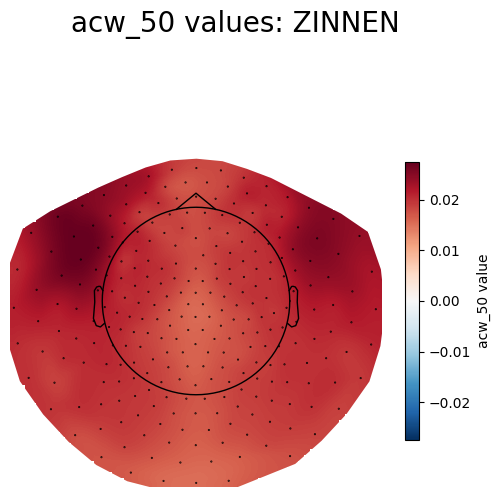

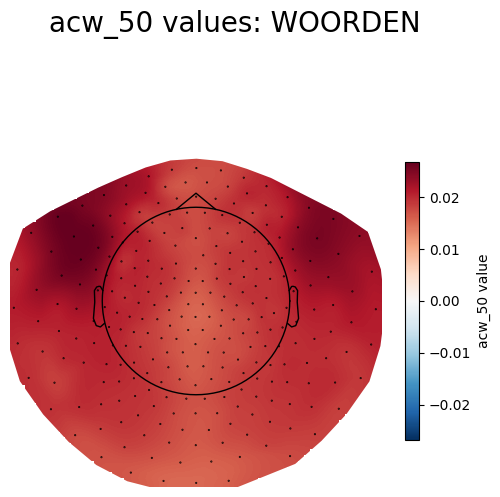

In [5]:
for comp in comparisons:
    # comp es algo como [groupA, groupB]
    for condition_group in comp:

        subj_df, topo_df, label = get_condition_data_all_levels(
            df=table_df,
            metric=metric,
            condition_group=condition_group,
            label_name=None  # o pones tu nombre aquí
        )

        values = topo_df[metric].values
        electrodes = topo_df["Elect"].values

        if len(values) != len(electrodes):
            raise ValueError("Los valores y los electrodos deben tener la misma longitud.")

        fig, ax = plt.subplots(figsize=(6, 6))

        im, _ = mne.viz.plot_topomap(
            data=values,
            pos=info,
            axes=ax,
            cmap='RdBu_r',
            vlim=(-np.max(np.abs(values)), np.max(np.abs(values))),
            mask=None,
            contours=0,
            show=False
        )

        fig.suptitle(f"{metric_name} values: {label}", fontsize=20)

        cbar = fig.colorbar(im, ax=ax, shrink=0.6)
        cbar.set_label(f"{metric_name} value")

        plt.show()

### linear plots

In [6]:
## old version withouth controling of size of bins


# # for comp_idx, comp in enumerate(comparisons):
# #     if not comp:
# #         continue

# #     dict_conditions_flat = {}

# #     # Si hay etiquetas definidas (solo event)
# #     if 'comparison_labels' in locals():
# #         label_A, label_B = comparison_labels[comp_idx]
# #     else:  # Block case: inventamos etiquetas
# #         label_A, label_B = comp

# #     for group_idx, condition_group in enumerate(comp):

# #         # Obtener data sujeto-nivel (para histogram)
# #         subj_df, topo_df, label = get_condition_data_all_levels(
# #             df=table_df,
# #             metric=metric,
# #             condition_group=condition_group,
# #             label_name=[label_A, label_B][group_idx]
# #         )

# #         # Extraer métricas por sujeto
# #         values_flat = subj_df[metric].values.flatten()
# #         dict_conditions_flat[label] = values_flat

# #     # ---- PLOT HIST + KDE ----
# #     plt.figure(figsize=(10, 5))
# #     colors = ['blue', 'red', 'green', 'orange', 'purple']

# #     for idx, (label, data) in enumerate(dict_conditions_flat.items()):

# #         counts, bins, _ = plt.hist(
# #             data,
# #             bins=100,
# #             alpha=0.4,
# #             label=f'{label}',
# #             color=colors[idx % len(colors)]
# #         )

# #         kde = gaussian_kde(data)
# #         x_vals = np.linspace(data.min(), data.max(), 300)
# #         scaled_kde = kde(x_vals) * len(data) * np.diff(bins)[0]

# #         plt.plot(
# #             x_vals,
# #             scaled_kde,
# #             linestyle='--',
# #             color=colors[idx % len(colors)],
# #             label=f'{label} (KDE)'
# #         )

# #     plt.xlabel(f"{metric_name}(s)")
# #     plt.ylabel("Number of values")

# #     # ✅ título con labels correctos
# #     plt.title(f"Distribution of {metric_name}: {label_A} vs {label_B}")

# #     plt.legend()
# #     plt.grid(True)
# #     plt.tight_layout()
# #     plt.show()
    
# #     for label, data in dict_conditions_flat.items():
# #         print(f"{label}: n = {len(data)}")

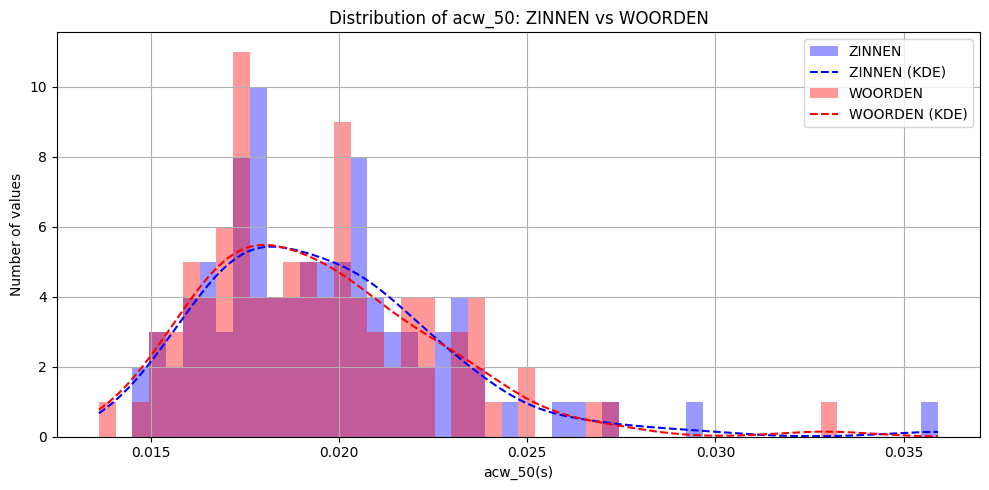

ZINNEN: n = 95
WOORDEN: n = 95


In [7]:
from scipy.stats import gaussian_kde
import numpy as np
import matplotlib.pyplot as plt

for comp_idx, comp in enumerate(comparisons):
    if not comp:
        continue

    dict_conditions_flat = {}

    # Etiquetas (event o block)
    if 'comparison_labels' in locals():
        label_A, label_B = comparison_labels[comp_idx]
    else:
        label_A, label_B = comp

    # --- Extraer datos ---
    for group_idx, condition_group in enumerate(comp):

        subj_df, topo_df, label = get_condition_data_all_levels(
            df=table_df,
            metric=metric,
            condition_group=condition_group,
            label_name=[label_A, label_B][group_idx]
        )

        values_flat = subj_df[metric].values.flatten()
        dict_conditions_flat[label] = values_flat

    # --- Definir bins comunes (mismo rango para todos) ---
    all_data = np.concatenate(list(dict_conditions_flat.values()))
    common_bins = np.histogram_bin_edges(all_data, bins=50)  # puedes ajustar el nº de bins

    # --- Plot ---
    plt.figure(figsize=(10, 5))
    colors = ['blue', 'red', 'green', 'orange', 'purple']

    # Eje X global para KDE
    x_vals = np.linspace(common_bins[0], common_bins[-1], 400)

    for idx, (label, data) in enumerate(dict_conditions_flat.items()):

        # Histograma con bins comunes
        plt.hist(
            data,
            bins=common_bins,
            density=False,           # ← cambia a True si quieres comparar formas, no recuentos
            alpha=0.4,
            label=f'{label}',
            color=colors[idx % len(colors)]
        )

        # KDE evaluada en rango común
        kde = gaussian_kde(data)
        kde_vals = kde(x_vals)

        # Escala compatible con histograma (a recuentos por bin)
        bin_width = np.diff(common_bins)[0]
        scaled_kde = kde_vals * len(data) * bin_width

        plt.plot(
            x_vals,
            scaled_kde,
            linestyle='--',
            color=colors[idx % len(colors)],
            label=f'{label} (KDE)'
        )

    plt.xlabel(f"{metric_name}(s)")
    plt.ylabel("Number of values")
    plt.title(f"Distribution of {metric_name}: {label_A} vs {label_B}")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Mostrar tamaño de muestra
    for label, data in dict_conditions_flat.items():
        print(f"{label}: n = {len(data)}")


In [8]:
## Plot for SLOPE


if "slope" in metric:

    print("\nPlotting ACW evolution because slope metric detected...")

    # Cargar solo columnas necesarias del archivo dinámico
    dyn_cols = ["Subject", "Condition", "Elect", "Window", "acw_50_window_all_elect_all_epoch_all"]
    
    name_table_comp =  f"dynamic_autocorrelation_subjects_all_{layer_script}.pickle"


    table_df_comp = pd.read_pickle(f"{path}\\{name_table_comp}")

    for comp_idx, comp in enumerate(comparisons):
        if not comp:
            continue

        # Etiquetas como antes
        if 'comparison_labels' in locals():
            label_A, label_B = comparison_labels[comp_idx]
        else:
            label_A, label_B = comp

        plt.figure(figsize=(8,5))

        for group_idx, condition_group in enumerate(comp):

            df_group = table_df_comp.query("Condition in @condition_group")

            # Asegurar float
            df_group["ACW"] = df_group["acw_50_window_all_elect_all_epoch_all"].astype(float)

            # Agrupar: mean por ventana por sujeto
            mean_by_subject = (
                df_group.groupby(["Subject","Window"])["ACW"]
                .mean()
                .reset_index()
            )

            # Luego media global por ventana
            curve = mean_by_subject.groupby("Window")["ACW"].mean()
            std = mean_by_subject.groupby("Window")["ACW"].std()

            label = [label_A,label_B][group_idx]

            plt.plot(curve.index, curve.values, label=label)
            plt.fill_between(curve.index, curve - std, curve + std, alpha=0.2)

        plt.title(f"ACW temporal evolution — {metric_name}")
        plt.xlabel("Sliding window index")
        plt.ylabel("ACW (s)")
        plt.legend()
        plt.grid(True)
        plt.show()

# General differences between woorden and zinnen conditions

In [7]:
comparisons

[[['zinnen_RC_plus', 'zinnen_RC_neg'], ['woorden_RC_plus', 'woorden_RC_neg']],
 [['zinnen_RC_plus'], ['zinnen_RC_neg']],
 [['zinnen_RC_neg_question_hit',
   'zinnen_RC_plus_question_hit',
   'woorden_RC_neg_question_hit',
   'woorden_RC_plus_question_hit'],
  ['zinnen_RC_neg_question_incorrect',
   'zinnen_RC_plus_question_incorrect',
   'woorden_RC_neg_question_incorrect',
   'woorden_RC_plus_question_incorrect']]]

In [14]:
from scipy.stats import permutation_test

for comp_idx, comp in enumerate(comparisons):
    if not comp:
        continue

    # Etiquetas para imprimir
    if 'comparison_labels' in locals():
        label_A, label_B = comparison_labels[comp_idx]
    else:  # block case
        label_A, label_B = comp

    # Obtener datos sujeto-nivel para cada condición
    subj_A, _, name_A = get_condition_data_all_levels(
        df=table_df,
        metric=metric,
        condition_group=comp[0],
        label_name=label_A
    )

    subj_B, _, name_B = get_condition_data_all_levels(
        df=table_df,
        metric=metric,
        condition_group=comp[1],
        label_name=label_B
    )
    merged = pd.merge(
        subj_A[["Subject", metric]],
        subj_B[["Subject", metric]],
        on="Subject",
        suffixes=("_A", "_B")
    )
    # print("Subjects A:", subj_A["Subject"].tolist())
    # print("Subjects B:", subj_B["Subject"].tolist())
    # Extraer valores por sujeto
    x = merged[f"{metric}_A"].values
    y = merged[f"{metric}_B"].values

    if '_elect_all_epoch_all' in metric:
        print("yes")
        metric_name = metric.replace('_elect_all_epoch_all', "")
    else:
        metric_name = metric
    print5(f"\n\n### Permutation Test: {name_A} vs {name_B} in {metric_name} ###")
    print(f"x = {name_A},  y = {name_B}")

    # Diferencia apareada
    diff = x - y
    

    X = diff[:, np.newaxis]
    T_obs, p_values, H0=mne.stats.permutation_t_test(X, n_permutations=10000, tail=tail, n_jobs=20, seed=None, verbose=None)
    
    
    print5(f"Statistic T: {T_obs[0]:.{number_decimals}f}")
    print5(f"p-value: {p_values[0]:.{number_decimals}f}")

    # Cohen's d for paired samples
    mean_diff = np.mean(diff)
    std_diff = np.std(diff, ddof=1)
    cohens_d = mean_diff / std_diff

    print5(f"Cohen's d (paired): {cohens_d:.{number_decimals}f}")

yes


### Permutation Test: ZINNEN vs WOORDEN in acw_50 ###
x = ZINNEN,  y = WOORDEN
Permuting 9999 times...


[Parallel(n_jobs=20)]: Using backend LokyBackend with 20 concurrent workers.
[Parallel(n_jobs=20)]: Done   6 out of  20 | elapsed:    0.8s remaining:    2.0s
[Parallel(n_jobs=20)]: Done  11 out of  20 | elapsed:    0.8s remaining:    0.7s
[Parallel(n_jobs=20)]: Done  16 out of  20 | elapsed:    0.9s remaining:    0.1s
[Parallel(n_jobs=20)]: Done  20 out of  20 | elapsed:    0.9s finished


Statistic T: 0.46554
p-value: 0.64210
Cohen's d (paired): 0.04802
yes


### Permutation Test: ZINNEN_RC+ vs ZINNEN_RC- in acw_50 ###
x = ZINNEN_RC+,  y = ZINNEN_RC-
Permuting 9999 times...
Statistic T: -1.07690
p-value: 1.00000
Cohen's d (paired): -0.11107


[Parallel(n_jobs=20)]: Using backend LokyBackend with 20 concurrent workers.
[Parallel(n_jobs=20)]: Done   6 out of  20 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=20)]: Done  11 out of  20 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=20)]: Done  16 out of  20 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=20)]: Done  20 out of  20 | elapsed:    0.0s finished


yes


### Permutation Test: CORRECT vs INCORRECT in acw_50 ###
x = CORRECT,  y = INCORRECT
Permuting 9999 times...
Statistic T: 0.59618
p-value: 0.55400
Cohen's d (paired): 0.06149


[Parallel(n_jobs=20)]: Using backend LokyBackend with 20 concurrent workers.
[Parallel(n_jobs=20)]: Done   6 out of  20 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=20)]: Done  11 out of  20 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=20)]: Done  16 out of  20 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=20)]: Done  20 out of  20 | elapsed:    0.0s finished


In [18]:
## old version using mean comparisons, not t-test with permutations

from scipy.stats import permutation_test

for comp_idx, comp in enumerate(comparisons):
    if not comp:
        continue

    # Etiquetas para imprimir
    if 'comparison_labels' in locals():
        label_A, label_B = comparison_labels[comp_idx]
    else:  # block case
        label_A, label_B = comp

    # Obtener datos sujeto-nivel para cada condición
    subj_A, _, name_A = get_condition_data_all_levels(
        df=table_df,
        metric=metric,
        condition_group=comp[0],
        label_name=label_A
    )

    subj_B, _, name_B = get_condition_data_all_levels(
        df=table_df,
        metric=metric,
        condition_group=comp[1],
        label_name=label_B
    )
    merged = pd.merge(
        subj_A[["Subject", metric]],
        subj_B[["Subject", metric]],
        on="Subject",
        suffixes=("_A", "_B")
    )
    # print("Subjects A:", subj_A["Subject"].tolist())
    # print("Subjects B:", subj_B["Subject"].tolist())
    # Extraer valores por sujeto
    x = merged[f"{metric}_A"].values
    y = merged[f"{metric}_B"].values

    if '_elect_all_epoch_all' in metric:
        print("yes")
        metric_name = metric.replace('_elect_all_epoch_all', "")
    else:
        metric_name = metric
    print5(f"\n\n### Permutation Test: {name_A} vs {name_B} in {metric_name} ###")
    print(f"x = {name_A},  y = {name_B}")

    # Diferencia apareada
    diff = x - y

    # Permutation statistic (paired)
    def paired_statistic(diff, _):
        return np.mean(diff)

    res = permutation_test(
        (diff, np.zeros_like(diff)),
        statistic=paired_statistic,
        vectorized=False,
        n_resamples=10000,
        alternative=alternative,
        random_state=42
    )

    # Outputs
    
    print5(f"Statistic: {res.statistic:.{number_decimals}f}")
    print5(f"p-value: {res.pvalue:.{number_decimals}f}")

    # Cohen's d for paired samples
    mean_diff = np.mean(diff)
    std_diff = np.std(diff, ddof=1)
    cohens_d = mean_diff / std_diff

    print5(f"Cohen's d (paired): {cohens_d:.{number_decimals}f}")

yes


### Permutation Test: ZINNEN vs WOORDEN in acw_50 ###
x = ZINNEN,  y = WOORDEN
Statistic: 0.00021
p-value: 0.00030
Cohen's d (paired): 0.35080


# Cluster analysis

## Datos a comparar

ahora tengo por cada condición: subject x epoch x channel

#### procedimiento

- promediar a nivel de epoca para tener subject x channel (luego probaré a hacerlo de otra manera sin promediar)

- ejecutar permutation cluster based analysis usando mi acw_zinnen vs mi acw_woorden  que va a estar como subject x channel

    - el cluster solo puede ser espacial, porque mis epocas son discontinuas, creo que esto es adjacency 

#### Resultados

T_obs: La estadística observada en cada punto.
clusters: Los clústeres formados por puntos significativos adyacentes.
cluster_p_values: Los valores p de cada clúster (ya corregidos por comparaciones múltiples).
H0: La distribución nula obtenida por permutaciones.



Supongo que clusters y sus valores de significacioón
Luego no se como se compara entre condiciones, pero de momemento vamos así

## Cluster in differences

In [11]:
# ##get adjacency value
# adjacency_reduced =  pd.read_pickle(channels_structure_path /f"adjacency_reduced_{modality}.pkl")
# ###print5(f"shape adjacency_reduced: {adjacency_reduced.shape}")

In [12]:
# ##note that condition_1 and condition_2 are 2D arrays with shape (n_subjects, n_channels)

# #here im using various things
# ##.query("Condition ==@cond") = [metric_cond_subj_epoch_mean_elect["Condition"]=cond]
# #pivot index="Subject",columns="Elect", values=metric) gives toy a a table with indexes and columns
# #to_numpy converts the table to a numpy array, removin names of indexes and columns

# for cond in condition_names:
#     if cond==condition_1_name:
#         print(f"x is {cond} and {condition_1_name}")
#         x= metric_cond_subj_epoch_mean_elect.query("Condition ==@cond").pivot(index="Subject",columns="Elect", values=metric).to_numpy()   
#     if cond==condition_2_name:
#         print(f"y is {cond} and {condition_2_name}")
#         y=metric_cond_subj_epoch_mean_elect.query("Condition ==@cond").pivot(index="Subject",columns="Elect", values=metric).to_numpy()   

# print(f"x.shape is {x.shape}")
# print(f"y.shape is {y.shape}")
# diff= x-y 
# print5(f"diff.shape is {diff.shape}")




# # as I´m going to apply differences to same subjects, i need a DEPENDENT t test kind of thing, 
# # so instead of mne.stats.permutation_cluster_test I´m going to use mne.stats.permutation_cluster_1samp_test

# # mne.stats.permutation_cluster_1samp_test(X, threshold=None, n_permutations=1024, tail=0, stat_fun=None, adjacency=None, n_jobs=None, seed=None, max_step=1, exclude=None, 
# #                                          step_down_p=0, t_power=1, out_type='indices', check_disjoint=False, buffer_size=1000, verbose=None)

# # as im going to put zinnen before woorden i need tail=1

# #instead of puting X with bot condigions, i will put the difference between them diff=zinnen-woorden
# # i modify the value of the tail to be -1, because i want to see if the values of zinnen are lower than the values of woorden
# from scipy.stats import t

# t_thresh = (threshold_direction ) * t.ppf(1 - p_cluster_value, df=len(subjects) - 1)


# t_obs_diff, clusters_diff, clusters_pv_diff, H0=mne.stats.permutation_cluster_1samp_test(diff, threshold=t_thresh, n_permutations=1024, tail=tail, 
#                                                                           stat_fun=None, adjacency=adjacency_reduced, n_jobs=15, seed=None, max_step=1, exclude=None,
#                                                                           step_down_p=0, t_power=1, out_type='indices', check_disjoint=False, buffer_size=1000, verbose=None)


# # Obtenemos los clusters como listas de índices
# # Filtrar clusters con p < 0.05
# #zip links clusters y p-values
# significant_clusters_diff = [
#     cluster for cluster, p in zip(clusters_diff, clusters_pv_diff) if p < 0.05
# ]

# print5(f"{len(significant_clusters_diff)} significative clusters found.")
# print5(f"{metric_name}Clusters significative: {significant_clusters_diff}")

In [13]:
# ###PLOTSS

# mask_diff = np.zeros(t_obs_diff.shape, dtype=bool)

# ##significant_clusters_diff is a list of tuples of arrays
# # cluster[0] is the electrodes of the  cluster
# for cluster in significant_clusters_diff:
#     mask_diff[cluster[0]] = True 



# ##in data i use the value of t_obs_diff
# #pos takes the information from evoked.info object
# #mask takes the mask_diff object
# #in t stat i don´t change it becausse the p value will be calculated with permutations, so no problem when using a parametric test,
# # even if the distribution is non parametric 

# # Crear figura y eje
# fig, ax = plt.subplots(figsize=(6, 6))

# # Dibujar el topomap
# im, _ = mne.viz.plot_topomap(
#     data=t_obs_diff,
#     pos=info,
#     mask=mask_diff,
#     axes=ax,
#     cmap='RdBu_r',
#     vlim=(-np.max(np.abs(t_obs_diff)), np.max(np.abs(t_obs_diff))),
#     mask_params=dict(marker='o', markerfacecolor='yellow', markersize=7),
#     contours=0,
#     show=False
# )

# # Añadir título
# fig.suptitle(f"{metric_name} Clusters in differences, p_threshold={p_cluster_value}", fontsize=14)

# # Añadir barra de color
# cbar = fig.colorbar(im, ax=ax, shrink=0.6)
# cbar.set_label("T-statistic value")

# # Mostrar el gráfico
# plt.show()

In [14]:
# # Filtrar solo condiciones de tipo "question"
# question_df = table_df.query("Condition.str.contains('question')", engine='python')

# # Contar epochs únicos por sujeto y condición
# epoch_counts = (
#     question_df
#     .groupby(["Subject", "Condition"])["Epoch"]
#     .nunique()              # cuenta epochs únicos por sujeto-condición
#     .groupby("Condition")   # luego suma los epochs de todos los sujetos
#     .sum()
# )

# print("\n--- Number of epochs per question condition ---")
# print(epoch_counts)


# # -------------------------------
# # Separar hits e incorrects
# # -------------------------------
# total_hit_epochs = epoch_counts[epoch_counts.index.str.contains("question_hit")].sum()
# total_incorrect_epochs = epoch_counts[epoch_counts.index.str.contains("question_incorrect")].sum()

# print("\n--- Summary by question type ---")
# print(f"Total hit epochs: {total_hit_epochs}")
# print(f"Total incorrect epochs: {total_incorrect_epochs}")
# print(f"Total question epochs: {total_hit_epochs + total_incorrect_epochs}")

In [15]:
# # import mne
# # import pandas as pd

# # # -------------------------------
# # # 1️⃣ Buscar todos los sujetos según modalidad
# # # -------------------------------
# # subj = []

# # for subdirectorio in general_datadir.iterdir():
# #     if modality == "visual":
# #         subject_prefix = 'sub-V1'
# #     elif modality == "auditory":
# #         subject_prefix = 'sub-A2'
        
# #     if subdirectorio.is_dir() and subdirectorio.name.startswith(subject_prefix):
# #         subj.append(subdirectorio.name)

# # # Eliminar sujetos que estén en la lista de exclusión
# # if 'subjects_remove' in locals() and len(subjects_remove) > 0:
# #     subj = [s for s in subj if s not in subjects_remove]

# # print(f"\nFound {len(subj)} valid subjects (after exclusion):")
# # print(subj)

# # # -------------------------------
# # # 2️⃣ Contar epochs por sujeto y condición
# # # -------------------------------
# # counts_summary = []

# # for s in subj:
# #     try:
# #         # Cargar epochs limpios del sujeto
# #         epochs_path = epochs_clean_path / f"{s}_epochs_{layer_script}-epo.fif"
# #         epochs = mne.read_epochs(epochs_path, preload=False)
# #         event_keys = epochs.event_id.keys()

# #         # Contar condiciones que contienen question_hit / question_incorrect
# #         cond_hit = {cond: len(epochs[cond]) for cond in event_keys if "question_hit" in cond}
# #         cond_incorrect = {cond: len(epochs[cond]) for cond in event_keys if "question_incorrect" in cond}

# #         # Añadir filas para cada condición
# #         for cond, n in cond_hit.items():
# #             counts_summary.append({"Subject": s, "Condition": cond, "Type": "hit", "Count": n})

# #         for cond, n in cond_incorrect.items():
# #             counts_summary.append({"Subject": s, "Condition": cond, "Type": "incorrect", "Count": n})

# #         print(f"{s}: {sum(cond_hit.values())} hits ({len(cond_hit)} conds), {sum(cond_incorrect.values())} incorrects ({len(cond_incorrect)} conds)")

# #         del epochs

# #     except FileNotFoundError:
# #         print(f"⚠️ Missing epochs file for {s}")
# #     except Exception as e:
# #         print(f"⚠️ Error reading {s}: {e}")

# # # -------------------------------
# # # 3️⃣ Crear DataFrame resumen
# # # -------------------------------
# # summary_df = pd.DataFrame(counts_summary)
# # summary_df = summary_df.sort_values(["Subject", "Condition"]).reset_index(drop=True)

# # # -------------------------------
# # # 4️⃣ Totales globales y resúmenes
# # # -------------------------------
# # total_hits = summary_df.query("Type == 'hit'")["Count"].sum()
# # total_incorrects = summary_df.query("Type == 'incorrect'")["Count"].sum()

# # print("\n--- Total counts across all valid subjects ---")
# # print(f"Total hits: {total_hits}")
# # print(f"Total incorrects: {total_incorrects}")

# # print("\n--- Per-condition summary (aggregated across valid subjects) ---")
# # print(summary_df.groupby(["Condition", "Type"])["Count"].sum())

# # print("\n--- Per-subject summary (aggregated) ---")
# # print(summary_df.groupby(["Subject", "Type"])["Count"].sum())

# # # (Opcional) guardar
# # # summary_df.to_csv(ACW_path / f"epoch_counts_question_{layer_script}_{modality}_filtered.csv", index=False)


In [16]:
print(table_df.groupby("Condition")["Subject"].nunique()
)

Condition
WOORDEN    95
ZINNEN     95
Name: Subject, dtype: int64
